In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# stepA_bs_parq = "./116_udlA_exec_batch.parquet"
# stepB_bs_parq = "./116_udlB_exec_batch.parquet"
# stepD_bs_parq = "./116_udlD_exec_batch.parquet"
# stepE_bs_parq = "./116_udlE_exec_batch.parquet"

stepA_bs_parq = "./215_udlA_exec_batch.parquet"
stepB_bs_parq = "./215_udlB_exec_batch.parquet"
stepD_bs_parq = "./215_udlD_exec_batch.parquet"
stepE_bs_parq = "./215_udlE_exec_batch.parquet"

In [3]:
stepA_bsdf = pd.read_parquet(stepA_bs_parq)
stepB_bsdf = pd.read_parquet(stepB_bs_parq)
stepD_bsdf = pd.read_parquet(stepD_bs_parq)
stepE_bsdf = pd.read_parquet(stepE_bs_parq)

In [4]:
label_map = {
"StepA": "TextEncoder",
"StepB": "VisionEncoder",
"StepD": "CrossAttn",
"StepE": "ColbertSearch"
}
color_map = {
    "StepA": "#b2182b",     # deep red
    "StepB": "#1a9850",     # forest green
    "StepD": "#2166ac",    # rich blue
    "StepE": "#d8b365"      # muted golden yellow
}


def median_every_n(arr, n=50, *, keep_partial=False):
    arr = np.asarray(arr)
    if keep_partial:
        return np.array([np.median(arr[i : i + n]) 
                         for i in range(0, arr.size, n)])
    else:
        trimmed = arr[: (arr.size // n) * n]
        return np.median(trimmed.reshape(-1, n), axis=1)

In [ ]:
stepa_ts_arr = np.array(stepA_bsdf["timestamp"])
stepb_ts_arr = np.array(stepB_bsdf["timestamp"])
stepd_ts_arr = np.array(stepD_bsdf["timestamp"])
stepe_ts_arr = np.array(stepE_bsdf["timestamp"])

stepa_ts_arr = (stepa_ts_arr - stepa_ts_arr[0]) / 250000.0  # Convert to seconds
stepb_ts_arr = (stepb_ts_arr - stepb_ts_arr[0]) / 1000000.0  # Convert to seconds
stepd_ts_arr = (stepd_ts_arr - stepd_ts_arr[0]) / 1000000.0  # Convert to seconds
stepe_ts_arr = (stepe_ts_arr - stepe_ts_arr[0]) / 1000000.0  # Convert to seconds


stepa_arr.size == stepb_arr.size == stepd_arr.size == stepe_arr.size, "All arrays must be of the same size"

NameError: name 'stepb_arr' is not defined

In [ ]:
stepa_bs_arr = np.array(stepA_bsdf[stepA_bsdf.keys()[-1]])
stepb_bs_arr = np.array(stepB_bsdf[stepB_bsdf.keys()[-1]])
stepd_bs_arr = np.array(stepD_bsdf[stepD_bsdf.keys()[-1]])
stepe_bs_arr = np.array(stepE_bsdf[stepE_bsdf.keys()[-1]])

stepa_bs_arr.size == stepb_bs_arr.size == stepd_bs_arr.size == stepe_bs_arr.size, "All arrays must be of the same size"

(True, 'All arrays must be of the same size')

In [8]:
# prepare raw
stepa_ts_arr = np.array(stepA_bsdf["timestamp"])
stepb_ts_arr = np.array(stepB_bsdf["timestamp"])
stepd_ts_arr = np.array(stepD_bsdf["timestamp"])
stepe_ts_arr = np.array(stepE_bsdf["timestamp"])

stepa_ts_arr = (stepa_ts_arr - stepa_ts_arr[0]) / 1000000.0  # Convert to seconds
stepb_ts_arr = (stepb_ts_arr - stepb_ts_arr[0]) / 1000000.0  # Convert to seconds
stepd_ts_arr = (stepd_ts_arr - stepd_ts_arr[0]) / 1000000.0  # Convert to seconds
stepe_ts_arr = (stepe_ts_arr - stepe_ts_arr[0]) / 1000000.0  # Convert to seconds

stepa_bs_arr = np.array(stepA_bsdf[stepA_bsdf.keys()[-1]])
stepb_bs_arr = np.array(stepB_bsdf[stepB_bsdf.keys()[-1]])
stepd_bs_arr = np.array(stepD_bsdf[stepD_bsdf.keys()[-1]])
stepe_bs_arr = np.array(stepE_bsdf[stepE_bsdf.keys()[-1]])
stepa_bs_arr.size == stepb_bs_arr.size == stepd_bs_arr.size == stepe_bs_arr.size, "All arrays must be of the same size"

# processing every n-th value
stepa_bs_arr = median_every_n(stepa_bs_arr, n=215)
stepa_ts_arr = median_every_n(stepa_ts_arr, n=215)

stepb_bs_arr = median_every_n(stepb_bs_arr, n=215)
stepb_ts_arr = median_every_n(stepb_ts_arr, n=215)

stepd_bs_arr = median_every_n(stepd_bs_arr, n=215)
stepd_ts_arr = median_every_n(stepd_ts_arr, n=215)

stepe_bs_arr = median_every_n(stepe_bs_arr, n=215)
stepe_ts_arr = median_every_n(stepe_ts_arr, n=215)

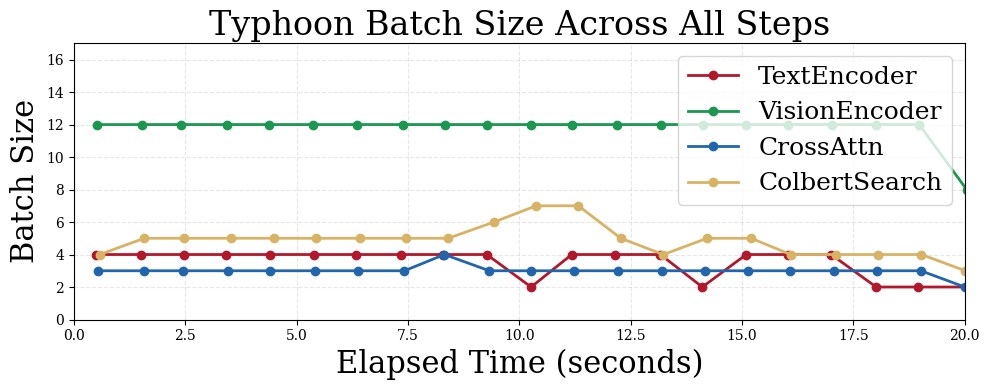

In [9]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern", "Latin Modern Roman", "CMU Serif", "DejaVu Serif"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

plt.figure(figsize=(10, 4))           # optional: size in inches
plt.plot(stepa_ts_arr, stepa_bs_arr, marker='o', label='TextEncoder', linewidth=2, color=color_map["StepA"])
plt.plot(stepb_ts_arr, stepb_bs_arr, marker='o', label='VisionEncoder', linewidth=2, color=color_map["StepB"])
plt.plot(stepd_ts_arr, stepd_bs_arr, marker='o', label='CrossAttn', linewidth=2, color=color_map["StepD"])
plt.plot(stepe_ts_arr, stepe_bs_arr, marker='o', label='ColbertSearch', linewidth=2, color=color_map["StepE"])
# 3) Add decorations
plt.title('Typhoon Batch Size Across All Steps', fontsize=24)
plt.xlabel('Elapsed Time (seconds)', fontsize=22)
plt.ylabel('Batch Size', fontsize=22)
plt.ylim(0, 17)
plt.xlim(0, 20)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right',fontsize=18)

plt.tight_layout()
plt.savefig("vortex_batch_size_across_all_steps.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()